<a href="https://colab.research.google.com/github/Carmen10-171/04MIAR_Aprendizaje-Supervisado/blob/main/Actividad_Computer_Vision_C1_M%C2%AA_Carmen_Cop%C3%A9_Soler_rev.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Convocatoria 1 - Proyecto 1

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
!pip install scikit-image scipy opencv-python matplotlib pandas
import sys
!{sys.executable} -m pip install scikit-image

from skimage import io, color, filters, morphology, measure
from skimage import io

from skimage.filters import threshold_otsu
from skimage.segmentation import flood
from skimage.segmentation import clear_border
from scipy.ndimage import binary_fill_holes
from scipy.spatial.distance import pdist
import cv2


#### 0) Cargar una de las imágenes histológicas

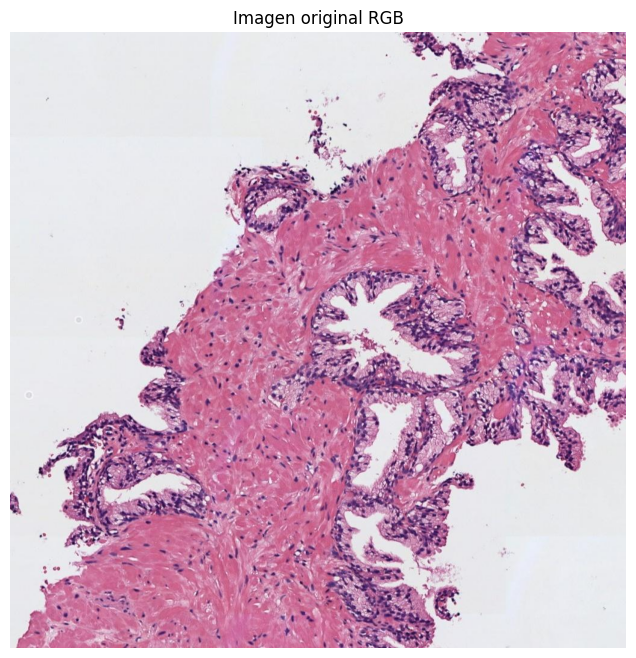

In [ ]:
# Utilizar la librería skimage.io para leer la imagen 'histo_x.jpg' en formato RGB.
# Normalizar la imagen para que los píxeles se encuentren en el rango [0, 1]
# Visualizar la imagen

# Cargar imagen
img = io.imread("histo_1.jpg")

# Normalizar

img = img.astype(np.float32) / 255.0

# Mostrar imagen

plt.figure(figsize=(8,8))
plt.imshow(img)
plt.title("Imagen original RGB")
plt.axis("off")
plt.show()


#### 1) Realizar una transformación de color para convertir la imagen al espacio de color CMYK

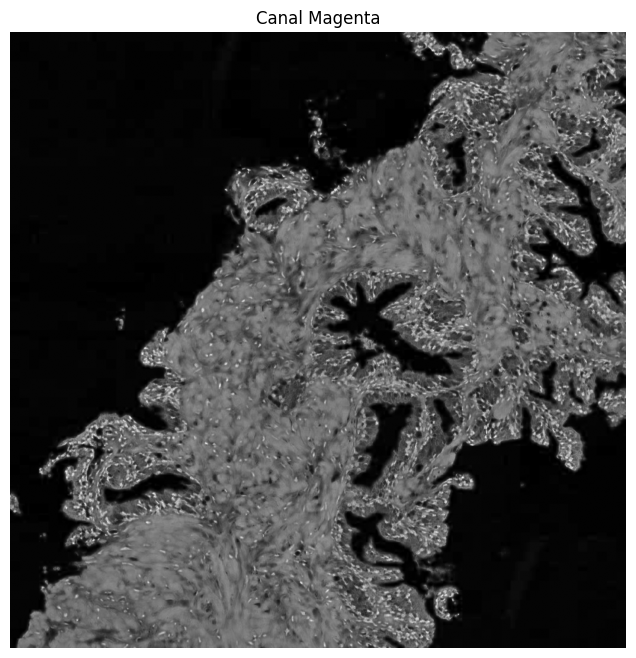

In [ ]:
# Extraer la componente magenta de la imagen (que corresponde a la región tisular)
# Visualizar la imagen del canal magenta

R = img[:,:,0]
G = img[:,:,1]
B = img[:,:,2]

K = 1 - np.max(img, axis=2)

C = (1 - R - K) / (1 - K + 1e-8)
M = (1 - G - K) / (1 - K + 1e-8)
Y = (1 - B - K) / (1 - K + 1e-8)

M = np.clip(M, 0, 1)

plt.figure(figsize=(8,8))
plt.imshow(M, cmap='gray')
plt.title("Canal Magenta")
plt.axis("off")
plt.show()

#### 2) Umbralizar la imagen para separar los píxeles del fondo de la región tisular

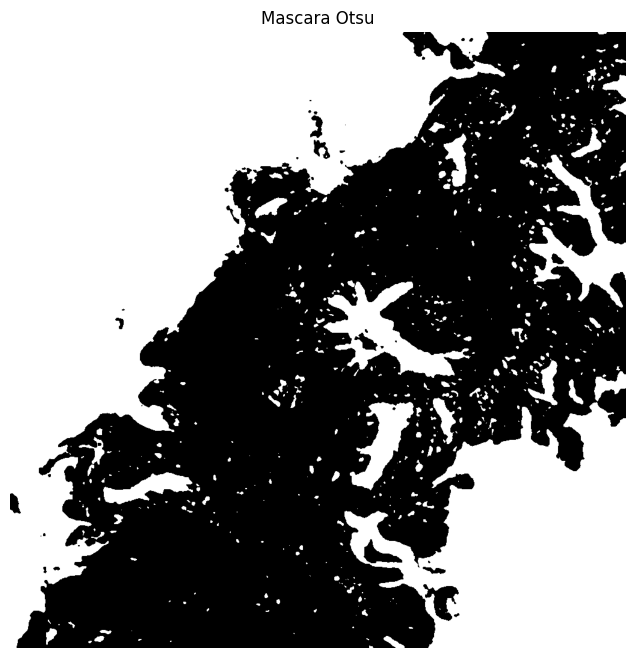

In [ ]:
# Aplicar un filtro gaussiano de tamaño 5x5 y después utilizar el método de Otsu de manera que
# los píxeles correspondientes al lumen y al background de la imagen sean 1s y el resto de los píxeles tengan un valor de 0.
# Nota: Recordar que el método de Otsu requiere como input una imagen en el rango [0-255] en formato "uint8".
# Visualizar la máscara resultante
M_blur = cv2.GaussianBlur(M, (5,5), 0)

M_uint8 = (M_blur * 255).astype(np.uint8)

th = threshold_otsu(M_uint8)

mask = M_uint8 < th

plt.figure(figsize=(8,8))
plt.imshow(mask, cmap='gray')
plt.title("Mascara Otsu")
plt.axis("off")
plt.show()

#### 3) Limpiar la imagen eliminando los artefactos de lumen (objetos blancos pequeños que no son lúmenes)

C:\Users\ccope\AppData\Local\Temp\ipykernel_3284\2080590875.py:7: FutureWarning: Parameter `min_size` is deprecated since version 0.26.0 and will be removed in 2.0.0 (or later). To avoid this warning, please use the parameter `max_size` instead. For more details, see the documentation of `remove_small_objects`. Note that the new threshold removes objects smaller than **or equal to** its value, while the previous parameter only removed smaller ones.
  mask_clean = morphology.remove_small_objects(


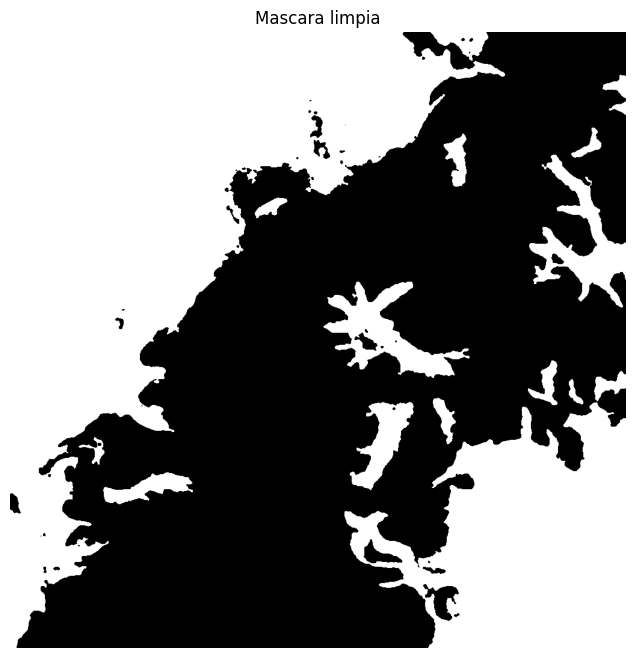

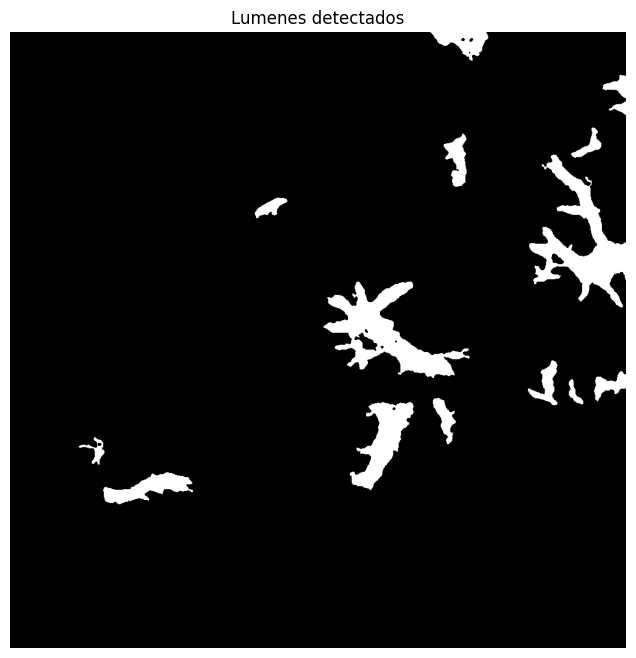

In [ ]:
# Utilizar la librería skimage.morphology.remove_small_objects para eliminar aquellos objetos cuya área sea menor a 300 píxeles
# Más información en https://scikit-image.org/docs/dev/api/skimage.morphology.html#skimage.morphology.remove_small_objects
# Visualizaer la máscara resultante

# Eliminar objetos pequeños

mask_clean = morphology.remove_small_objects(
    mask.astype(bool),
    min_size=300
)

plt.figure(figsize=(8,8))
plt.imshow(mask_clean, cmap='gray')
plt.title("Mascara limpia")
plt.axis("off")
plt.show()

# Region Growing

seed1 = (0, 0)

seed2 = (
    mask_clean.shape[0] - 1,
    mask_clean.shape[1] - 1
)

background1 = flood(mask_clean, seed1)
background2 = flood(mask_clean, seed2)

background = background1 | background2

lumens = mask_clean.copy()
lumens[background] = False

plt.figure(figsize=(8,8))
plt.imshow(lumens, cmap='gray')
plt.title("Lumenes detectados")
plt.axis("off")
plt.show()

#### 4) Rellenar con 0s el fondo de la imagen para quedarnos únicamente con los lúmenes

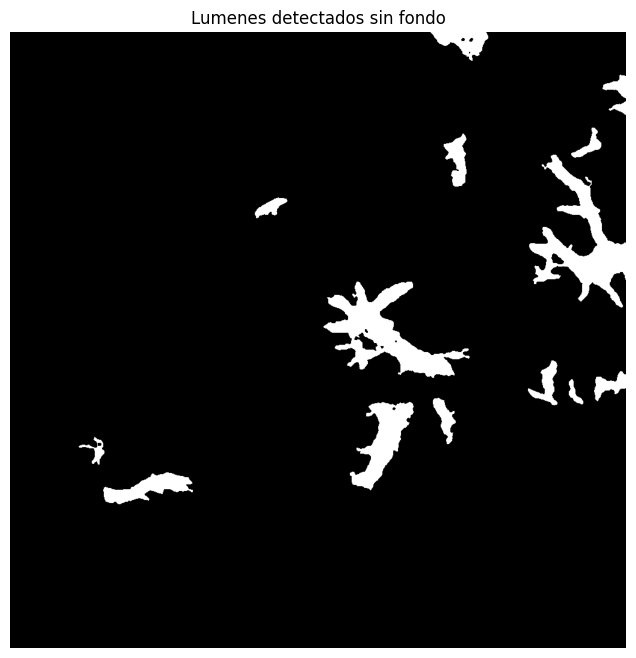

In [ ]:
# Aplicar el algoritmo de expansión a partir de semillas (region growing) de manera que únicamente los lúmenes sean blancos
# y el resto de la imagen negra. Pista: utilizar dos semillas. Nota: Se pueden fijar las semillas de manera manual, pero
# se valorará positivamente a aquell@s que desarrollen una función para encontrarlas automáticamente.
# Visualizar la máscara resultante.

# ============================================================
# 4) REGION GROWING PARA ELIMINAR EL FONDO
# ============================================================
from skimage.segmentation import flood

# Definir las 4 esquinas como semillas para atrapar todo el fondo exterior
h, w = mask_clean.shape
bg1 = flood(mask_clean, (0, 0))
bg2 = flood(mask_clean, (0, w - 1))
bg3 = flood(mask_clean, (h - 1, 0))
bg4 = flood(mask_clean, (h - 1, w - 1))

# Unir todo el fondo detectado
background = bg1 | bg2 | bg3 | bg4

# Eliminar el fondo para aislar solo lúmenes internos
lumens = mask_clean.copy()
lumens[background] = False

plt.figure(figsize=(8, 8))
plt.imshow(lumens, cmap='gray')
plt.title("Lumenes detectados sin fondo")
plt.axis("off")
plt.show()



#### 5) Rellenar los objetos de los lúmenes

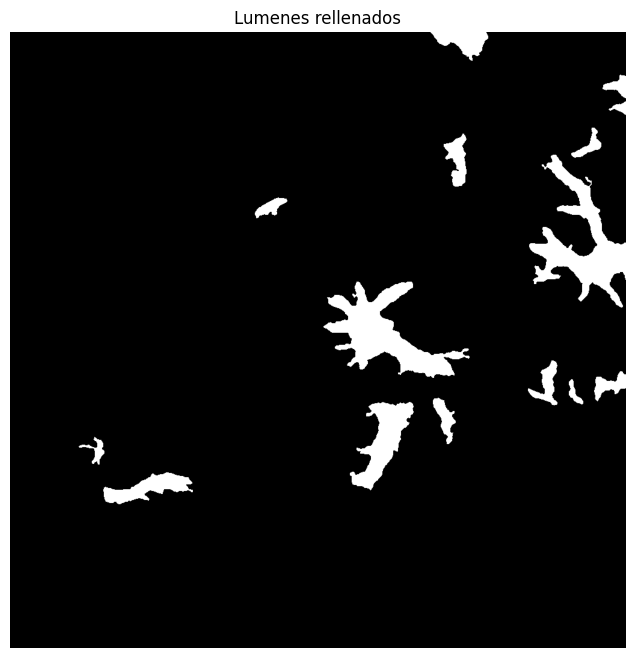

In [ ]:
# Rellenar los lúmenes con la función binary_fill_holes de la librería scipy.ndimage.morphology
# Visualizar la máscara resultante

# ============================================================
# 5) RELLENAR LOS OBJETOS DE LOS LÚMENES
# ============================================================
from scipy.ndimage import binary_fill_holes

# Rellenar los huecos internos únicamente de la máscara limpia sin fondo (lumens)
lumens_filled = binary_fill_holes(lumens)

plt.figure(figsize=(8, 8))
plt.imshow(lumens_filled, cmap='gray')
plt.title("Lumenes rellenados")
plt.axis("off")
plt.show()



#### 6) Detectar y dibujar los contornos de los lúmenes sobre la imagen original

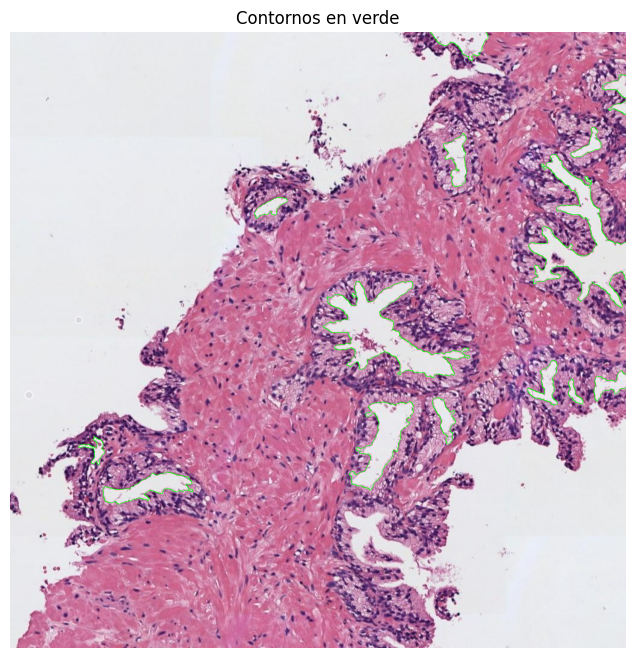

In [ ]:
# Dibujar los contornos de los lúmenes en color verde sobre la imagen original RGB. Nota: Utilizar los flags necesarios
# para que los contornos en verde sean perfectamente visibles.
# Visualizar la imagen superpuesta

# ============================================================
# 6) DIBUJAR CONTORNOS EN VERDE
# ============================================================
from skimage import measure

contours = measure.find_contours(lumens_filled, level=0.5)
overlay = img.copy()

for contour in contours:
    contour = contour.astype(int)
    for r, c in contour:
        if 0 <= r < overlay.shape[0] and 0 <= c < overlay.shape[1]:
            overlay[r, c] = [0, 1, 0]

plt.figure(figsize=(8, 8))
plt.imshow(overlay)
plt.title("Contornos en verde")
plt.axis("off")
plt.show()



#### 7) Identificar y cropear el lumen más grande

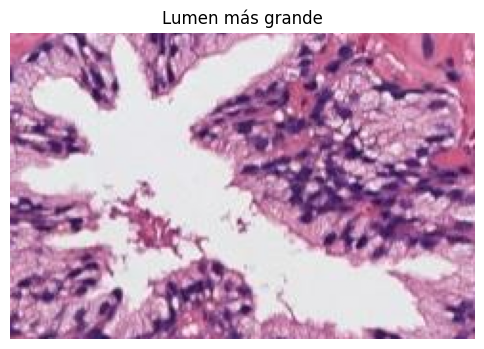

In [ ]:
# Determinar cuál es el lumen de mayor área y hacer un crop del mismo sobre la imagen original RGB.
# Visualizar el lumen cropeado.
# ============================================================
# 7 CROPEAR LUMEN MAYOR
# ============================================================
import pandas as pd
from IPython.display import display
from skimage.segmentation import clear_border
from scipy.spatial.distance import pdist

# Eliminar cualquier objeto o borde pegado al marco exterior
lumens_internos = clear_border(lumens_filled)

labels = measure.label(lumens_internos)
props = measure.regionprops(labels)

# Seleccionar el lumen real de mayor área
largest = max(props, key=lambda x: x.area)

# Visualizar el recorte
minr, minc, maxr, maxc = largest.bbox
crop_rgb = img[minr:maxr, minc:maxc]

plt.figure(figsize=(6, 6))
plt.imshow(crop_rgb)
plt.title("Lumen más grande")
plt.axis("off")
plt.show()



#### 8) Extraer 13 características geométricas que permitan caracterizar el lumen recortado

In [ ]:
# Calcular las siguientes características del crop del lumen de mayor área, redondeando su valor hasta el cuarto decimal.
# 1) Área
# 2) Área de la bounding box
# 3) Área convexa
# 4) Exentricidad
# 5) Diámetro equivalente
# 6) Extensión
# 7) Diámetro Feret
# 8) Longitud del eje mayor
# 9) Longitud del eje menor
# 10) Orientación
# 11) Perímetro
# 12) Solidez
# 13) Compacidad
# ============================================================
# 8) EXTRAER LAS 13 CARACTERÍSTICAS GEOMÉTRICAS SOBRE EL LUMEN
# ============================================================

# Extraer las 13 características geométricas
area = round(float(largest.area), 4)
bbox_area = round(float((largest.bbox[2] - largest.bbox[0]) * (largest.bbox[3] - largest.bbox[1])), 4)
convex_area = round(float(largest.area_convex), 4)
eccentricity = round(float(largest.eccentricity), 4)
equivalent_diameter = round(float(largest.equivalent_diameter_area), 4)
extent = round(float(largest.extent), 4)

try:
    feret_diameter = round(float(largest.feret_diameter_max), 4)
except AttributeError:
    coords = largest.coords
    feret_diameter = round(float(np.max(pdist(coords))), 4) if len(coords) > 1 else 0.0

major_axis_length = round(float(largest.axis_major_length), 4)
minor_axis_length = round(float(largest.axis_minor_length), 4)
orientation = round(float(largest.orientation), 4)
perimeter = round(float(largest.perimeter), 4)
solidity = round(float(largest.solidity), 4)
compactness = round(float((4 * np.pi * area) / (perimeter ** 2 + 1e-8)), 4)

# Tabla oficial
tabla_features = pd.DataFrame({
    "Nº": range(1, 14),
    "Característica": [
        "Área", "Área Bounding Box", "Área Convexa", "Excentricidad",
        "Diámetro Equivalente", "Extensión", "Diámetro Feret",
        "Longitud Eje Mayor", "Longitud Eje Menor", "Orientación",
        "Perímetro", "Solidez", "Compacidad"
    ],
    "Valor": [
        area, bbox_area, convex_area, eccentricity, equivalent_diameter,
        extent, feret_diameter, major_axis_length, minor_axis_length,
        orientation, perimeter, solidity, compactness
    ]
})

print("\n===== CARACTERÍSTICAS GEOMÉTRICAS DEL LUMEN DE MAYOR ÁREA =====")
display(tabla_features.style.hide(axis='index'))


===== CARACTERÍSTICAS GEOMÉTRICAS DEL LUMEN DE MAYOR ÁREA =====


Nº,Característica,Valor
1,Área,13919.000000
2,Área Bounding Box,38880.000000
3,Área Convexa,28787.000000
4,Excentricidad,0.845900
5,Diámetro Equivalente,133.124800
6,Extensión,0.358000
7,Diámetro Feret,257.233400
8,Longitud Eje Mayor,236.561700
9,Longitud Eje Menor,126.159300
10,Orientación,1.012400
